# Selección de Factores - Vinos


* Correlaciones:  relaciones lineales entre variables numéricas







In [2]:
# Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np # matrices y vectores
import matplotlib.pyplot as plt # gráfica

# 1. Preparación de datos

In [3]:
#Cargamos los datos
red_wine = pd.read_csv("red_wine_quality.csv") #tabla 1
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
#Corrección tipos de datos - no hay ningún dato de tipo categoría
#data=data.astype('category')
#data.info()

In [6]:
# Revisamos si tenemos registros repetidos
red_wine.duplicated(subset=red_wine.columns.drop('Id')).sum()

np.int64(125)

In [7]:
# Sólo dejamos el registro mas reciente
red_wine.drop_duplicates(subset=red_wine.columns.drop('Id'),
                         keep='last', # keep last para conservar el ultimo
                         inplace=True) # inplace True para reemplazar sobre el mismo df

# Verificamos de nuevo si tenemos registros repetidos
red_wine.duplicated(subset=red_wine.columns.drop('Id')).sum()

np.int64(0)

In [8]:
# Se cargan los datos de la tabla 2
white_wine = pd.read_csv("white_wine_quality.csv", sep=';') # este archivo usa punto y coma como separador
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [9]:
white_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [10]:
# Revisamos si tenemos registros repetidos en white_wine
white_wine.duplicated().sum()

np.int64(937)

In [11]:
# Sólo dejamos el registro mas reciente
white_wine.drop_duplicates(keep='last', inplace=True)

# Verificamos de nuevo si tenemos registros repetidos
white_wine.duplicated().sum()

np.int64(0)

In [12]:
# Marcamos el origen de cada tabla antes de unirlas
red_wine['tipo'] = 'tinto'
white_wine['tipo'] = 'blanco'

In [13]:
# Unión
data = pd.concat([red_wine, white_wine],
                 ignore_index=True) # ignore_index para renumerar las filas
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,tipo
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1.0,tinto
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2.0,tinto
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3.0,tinto
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4.0,tinto
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5.0,tinto


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4979 entries, 0 to 4978
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4979 non-null   float64
 1   volatile acidity      4979 non-null   float64
 2   citric acid           4979 non-null   float64
 3   residual sugar        4979 non-null   float64
 4   chlorides             4979 non-null   float64
 5   free sulfur dioxide   4979 non-null   float64
 6   total sulfur dioxide  4979 non-null   float64
 7   density               4979 non-null   float64
 8   pH                    4979 non-null   float64
 9   sulphates             4979 non-null   float64
 10  alcohol               4979 non-null   float64
 11  quality               4979 non-null   int64  
 12  Id                    1018 non-null   float64
 13  tipo                  4979 non-null   object 
dtypes: float64(12), int64(1), object(1)
memory usage: 544.7+ KB


In [15]:
# Variable objetivo: el vino es bueno si los catadores le dieron un 6 o más de nota
data['calidad'] = np.where(data['quality'] >= 6, 'Buena', 'Mala')
data = data.drop('quality',axis=1) # eliminamos quality para no darle la respuesta al modelo
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id,tipo,calidad
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1.0,tinto,Mala
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2.0,tinto,Mala
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3.0,tinto,Buena
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4.0,tinto,Mala
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5.0,tinto,Mala


In [16]:
data.to_csv('wine_data.csv', index=False)

In [17]:
# Corrección del tipo de datos object a categorías
data['tipo']=data['tipo'].astype('category')
data['calidad']=data['calidad'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4979 entries, 0 to 4978
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         4979 non-null   float64 
 1   volatile acidity      4979 non-null   float64 
 2   citric acid           4979 non-null   float64 
 3   residual sugar        4979 non-null   float64 
 4   chlorides             4979 non-null   float64 
 5   free sulfur dioxide   4979 non-null   float64 
 6   total sulfur dioxide  4979 non-null   float64 
 7   density               4979 non-null   float64 
 8   pH                    4979 non-null   float64 
 9   sulphates             4979 non-null   float64 
 10  alcohol               4979 non-null   float64 
 11  Id                    1018 non-null   float64 
 12  tipo                  4979 non-null   category
 13  calidad               4979 non-null   category
dtypes: category(2), float64(12)
memory usage: 476.9 KB


# 2. Eliminar variables irrelevantes y redundantes

* Irrelevantes: cedulas, ids, nombres, telefonos, direcciones, códigos.
* Redundantes: validación por fórmula matemática que están repetidas

In [18]:
# Variables irrelevantes para el proceso de minería
data = data.drop('Id',axis=1) # eliminamos el Id por ser irrelevante, axis=1 indica que es una columna
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo,calidad
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,tinto,Mala
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,tinto,Mala
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,tinto,Buena
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,tinto,Mala
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,tinto,Mala


# 3. Descripción estadística

<Axes: xlabel='calidad'>

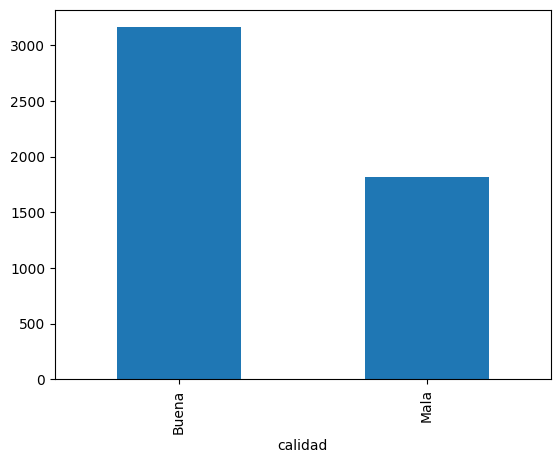

In [19]:
#Conocemos las variables categóricas
data['calidad'].value_counts().plot(kind='bar')

<Axes: xlabel='tipo'>

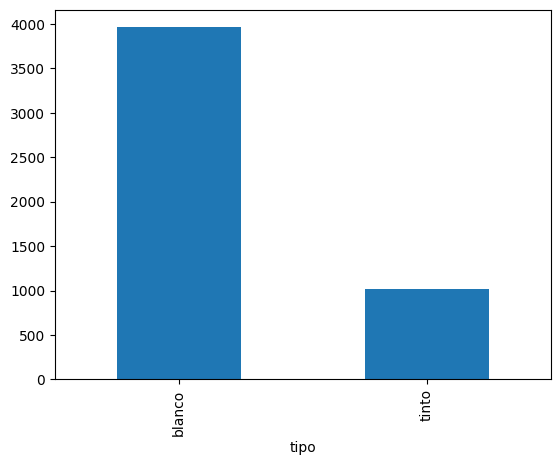

In [20]:
#Conocemos las variables categóricas
data['tipo'].value_counts().plot(kind='bar')

In [21]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000
mean,7.135640,0.332267,0.320934,5.221621,0.054345,30.955312,118.614782,0.994385,3.219185,0.524386,10.561367
std,1.248562,0.160559,0.143151,4.585347,0.034388,17.804445,55.201299,0.002973,0.159831,0.143161,1.194316
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.700000,0.037000,18.000000,84.000000,0.992000,3.110000,0.430000,9.500000
50%,6.900000,0.290000,0.310000,2.900000,0.046000,29.000000,120.000000,0.994400,3.210000,0.500000,10.400000
75%,7.600000,0.390000,0.390000,7.800000,0.060000,42.000000,157.000000,0.996600,3.320000,0.590000,11.400000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>, <Axes: >]], dtype=object)

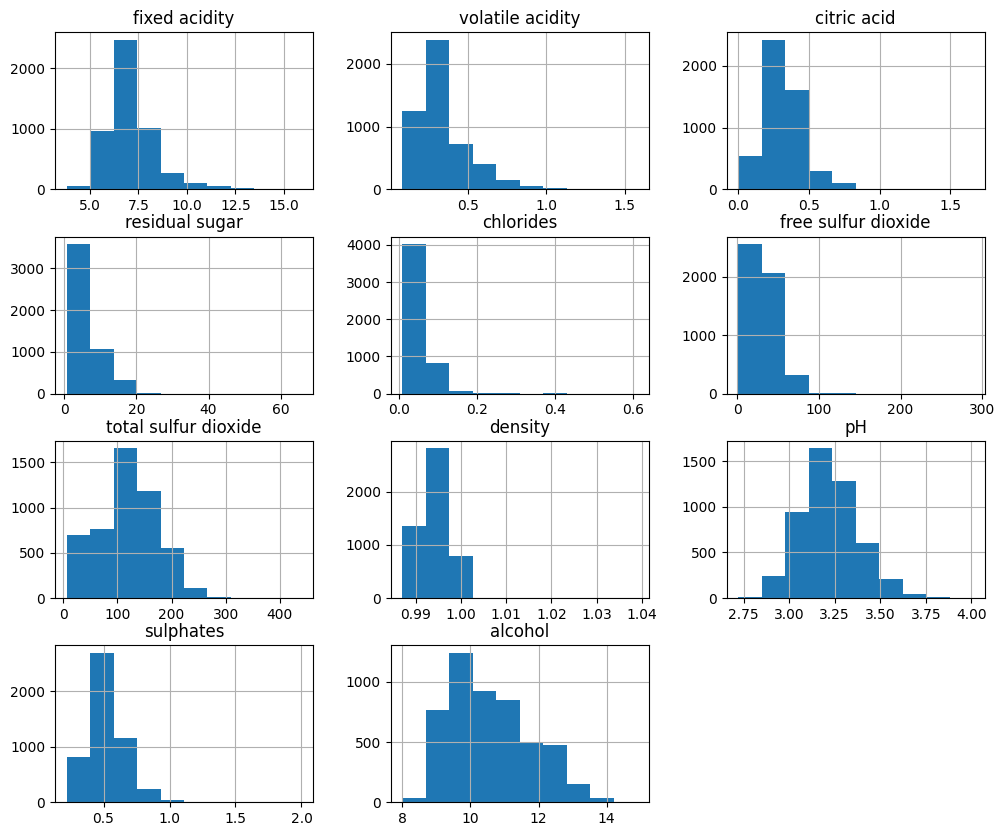

In [22]:
data.hist(figsize=(12,10))

<Axes: >

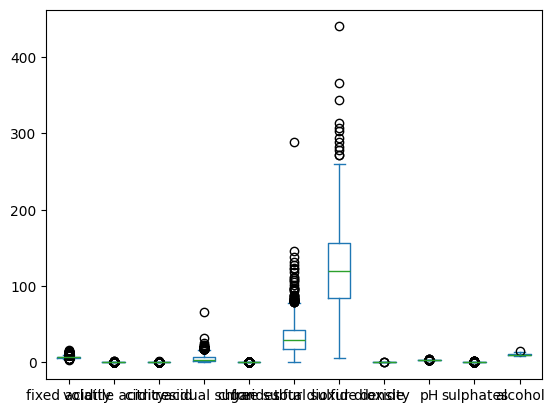

In [23]:
data.plot.box()

In [24]:
# Transformaciones
# Convertimos a número todas las variables (incluyendo la objetivo)

#Dummies para variable con más de 2 categorías
# data = pd.get_dummies(data, columns=['Clase'], drop_first=False, dtype=int)

#Dummies para variable con 2 categorías
data = pd.get_dummies(data, columns=['tipo', 'calidad'],  drop_first=True, dtype=int)

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo_tinto,calidad_Mala
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1,1
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1,1
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1,0
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,1,1


# 4. Correlaciones: relaciones lineales

* No se normaliza

In [25]:
# Correlaciones
correlaciones=data.corr()
correlaciones

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo_tinto,calidad_Mala
fixed acidity,1.000000,0.213707,0.315768,-0.076458,0.276774,-0.260079,-0.292482,0.453856,-0.283553,0.272370,-0.104279,0.468149,0.073922
volatile acidity,0.213707,1.000000,-0.362212,-0.136698,0.354349,-0.328801,-0.370977,0.285559,0.215387,0.212960,-0.049261,0.635578,0.258840
citric acid,0.315768,-0.362212,1.000000,0.146056,0.068717,0.133014,0.195951,0.100098,-0.325124,0.054112,-0.018293,-0.184640,-0.074501
residual sugar,-0.076458,-0.136698,0.146056,1.000000,-0.096464,0.385068,0.474549,0.572063,-0.227084,-0.153125,-0.324637,-0.298234,0.060417
chlorides,0.276774,0.354349,0.068717,-0.096464,1.000000,-0.156330,-0.233905,0.362484,0.016953,0.367208,-0.278684,0.484208,0.180231
free sulfur dioxide,-0.260079,-0.328801,0.133014,0.385068,-0.156330,1.000000,0.707868,0.045523,-0.127414,-0.176949,-0.183650,-0.435875,-0.038212
total sulfur dioxide,-0.292482,-0.370977,0.195951,0.474549,-0.233905,0.707868,1.000000,0.068097,-0.198179,-0.243392,-0.274440,-0.663955,0.065185
density,0.453856,0.285559,0.100098,0.572063,0.362484,0.045523,0.068097,1.000000,0.021048,0.257112,-0.681231,0.394786,0.285473
pH,-0.283553,0.215387,-0.325124,-0.227084,0.016953,-0.127414,-0.198179,0.021048,1.000000,0.176945,0.100667,0.292848,-0.047510
sulphates,0.272370,0.212960,0.054112,-0.153125,0.367208,-0.176949,-0.243392,0.257112,0.176945,1.000000,-0.015275,0.469009,-0.042022


In [26]:
#Correlaciones con la variable de interés
cor_variable_interes=correlaciones.loc['calidad_Mala']
cor_variable_interes

,calidad_Mala
fixed acidity,0.073922
volatile acidity,0.258840
citric acid,-0.074501
residual sugar,0.060417
chlorides,0.180231
free sulfur dioxide,-0.038212
total sulfur dioxide,0.065185
density,0.285473
pH,-0.047510
sulphates,-0.042022


# 5. Interpretación

<BarContainer object of 13 artists>

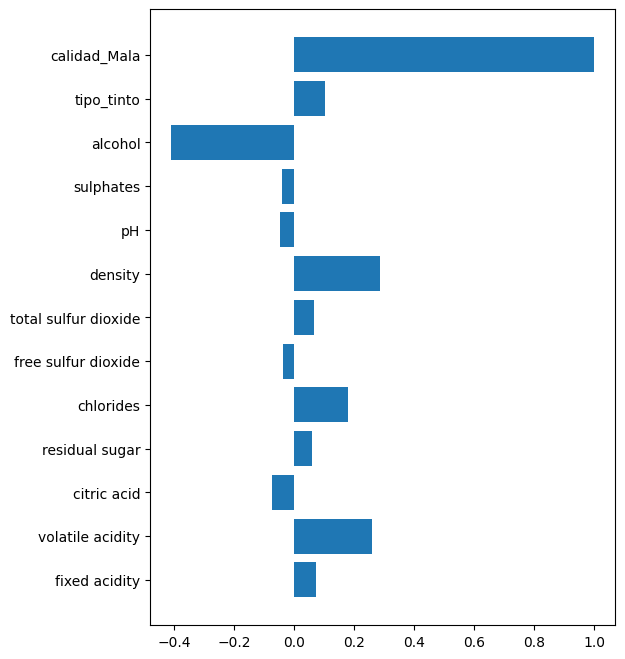

In [27]:
plt.figure(figsize=(6, 8))
plt.barh(y = data.columns, width=cor_variable_interes)

**Relación con la variable objetivo** (correlación con `calidad_Mala`: positivo = más asociado a vinos malos, negativo = a vinos buenos)

| Variable | Correlación | Lectura |
|---|---|---|
| alcohol | -0.41 | La más relevante: a más alcohol, mejor calidad |
| density | 0.29 | Vinos más densos tienden a ser malos (la densidad baja cuando sube el alcohol) |
| volatile acidity | 0.26 | Acidez volátil alta (sabor a vinagre) se asocia a vinos malos |
| chlorides | 0.18 | Más cloruros (sal), peor calidad |
| tipo_tinto | 0.10 | Los tintos tienen un poco más de proporción de vinos malos |
| fixed acidity, citric acid, residual sugar, free y total sulfur dioxide, pH, sulphates | entre -0.08 y 0.08 | Relación lineal muy débil con la calidad |

**Variables redundantes** (correlación alta entre predictoras):
* free sulfur dioxide y total sulfur dioxide: 0.71 (el SO₂ libre es parte del total)
* density y alcohol: -0.68
* density y residual sugar: 0.57

Ningún par supera 0.8, por lo que no hay variables tan redundantes como para eliminarlas.

**Decisión: se conservan las 11 variables numéricas y el tipo de vino.**
1. La correlación de Pearson solo mide relaciones lineales. Una variable con correlación baja puede ser útil en combinación con otras, por ejemplo el SO₂ total cambia mucho según el tipo de vino (correlación -0.66 con tipo_tinto), algo que los modelos no lineales (árboles, red neuronal, SVM) sí pueden aprovechar.
2. No hay variables redundantes ni irrelevantes (el `Id` ya se eliminó).
3. Son solo 12 predictoras para 4979 registros, así que conservarlas no genera problemas de dimensionalidad.

Las variables con mayor peso esperado en los modelos son alcohol, densidad, acidez volátil y cloruros.